## Setup

In [1]:
import os
import re
import pickle
import math
import copy
import random
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset
from torchvision import transforms as T

from transformers import (
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    VisionEncoderDecoderModel,
    AutoImageProcessor,
    AutoTokenizer,
    default_data_collator,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

os.environ["WANDB_DISABLED"] = "true"


Using device: cuda


In [2]:
class config:
    ENCODER = "facebook/vit-mae-base" 
    DECODER = "gpt2"
    
    TRAIN_BATCH_SIZE = 64
    VAL_BATCH_SIZE = 64
    LR = 5e-5
    SEED = 42
    EPOCHS = 10
    
    DATA_FOLDER_PATH = "../data"
    IMAGE_FOLDER_PATH = f"{DATA_FOLDER_PATH}/Images"
    CAPTION_FILE_PATH = f"{DATA_FOLDER_PATH}/captions.txt"

random.seed(config.SEED)
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)

## Preprocessing

In [3]:
def parse_captions_to_dataframe(csv_file):
    """Parses the Flickr8k captions file and returns a DataFrame and a grouped dictionary."""
    imgid2captions = defaultdict(list)
    
    df = pd.read_csv(csv_file)
    for _, row in df.iterrows():
        img_id, caption = row['image'], row['caption']
        if img_id and isinstance(caption, str):
            imgid2captions[img_id].append(caption)
            
    return df, imgid2captions

full_df, imgid2captions = parse_captions_to_dataframe(config.CAPTION_FILE_PATH)
img_ids = list(imgid2captions.keys())
random.shuffle(img_ids)

train_split_idx = int(0.8 * len(img_ids))
val_split_idx = int(0.9 * len(img_ids))

train_ids = img_ids[:train_split_idx]
val_ids = img_ids[train_split_idx:val_split_idx]
test_ids = img_ids[val_split_idx:]

train_df = full_df[full_df['image'].isin(train_ids)].reset_index(drop=True)
val_df = full_df[full_df['image'].isin(val_ids)].reset_index(drop=True)
test_df = full_df[full_df['image'].isin(test_ids)].reset_index(drop=True)

val_dict_for_cider = {iid: imgid2captions[iid] for iid in val_ids}
train_dict = {iid: imgid2captions[iid] for iid in train_ids}
val_dict = {iid: imgid2captions[iid] for iid in val_ids}
test_dict = {iid: imgid2captions[iid] for iid in test_ids}

print(f"Total Images: {len(img_ids)}")
print(f"Training Images: {len(train_ids)} | Training Samples: {len(train_df)}")
print(f"Validation Images: {len(val_ids)} | Validation Samples: {len(val_df)}")
print(f"Test Images: {len(test_ids)}")

Total Images: 8091
Training Images: 6472 | Training Samples: 32360
Validation Images: 809 | Validation Samples: 4045
Test Images: 810


In [4]:
image_processor = AutoImageProcessor.from_pretrained(config.ENCODER)
tokenizer = AutoTokenizer.from_pretrained(config.DECODER)
tokenizer.pad_token = tokenizer.eos_token  
target_size = (image_processor.size["height"], image_processor.size["width"])

train_transform = T.Compose([
    T.Resize(target_size),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=image_processor.image_mean, std=image_processor.image_std),
])

val_transform = T.Compose([
    T.Resize(target_size),
    T.ToTensor(),
    T.Normalize(mean=image_processor.image_mean, std=image_processor.image_std),
])

class ImageCaptioningDataset(Dataset):
    def __init__(self, df, root_dir, tokenizer, image_processor, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_length = 50 

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["image"])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            pixel_values = self.transform(image)
        
        tokenized_caption = self.tokenizer(
            row["caption"],
            padding="max_length",
            max_length=self.max_length,
            truncation=True,
        ).input_ids

        labels = torch.tensor(tokenized_caption)
        labels[labels == self.tokenizer.pad_token_id] = -100 

        return {"pixel_values": pixel_values, "labels": labels}

train_dataset = ImageCaptioningDataset(train_df, config.IMAGE_FOLDER_PATH, tokenizer, image_processor, transform=train_transform)
val_dataset = ImageCaptioningDataset(val_df, config.IMAGE_FOLDER_PATH, tokenizer, image_processor, transform=val_transform)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


## Model Training

In [5]:
model = VisionEncoderDecoderModel.from_encoder_decoder_pretrained(
    config.ENCODER, config.DECODER
).to(DEVICE)

model.config.decoder_start_token_id = tokenizer.bos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.vocab_size = model.config.decoder.vocab_size

model.config.max_length = 50
model.config.num_beams = 4
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3

Some weights of GPT2LMHeadModel were not initialized from the model checkpoint at gpt2 and are newly initialized: ['h.0.crossattention.c_attn.bias', 'h.0.crossattention.c_attn.weight', 'h.0.crossattention.c_proj.bias', 'h.0.crossattention.c_proj.weight', 'h.0.crossattention.q_attn.bias', 'h.0.crossattention.q_attn.weight', 'h.0.ln_cross_attn.bias', 'h.0.ln_cross_attn.weight', 'h.1.crossattention.c_attn.bias', 'h.1.crossattention.c_attn.weight', 'h.1.crossattention.c_proj.bias', 'h.1.crossattention.c_proj.weight', 'h.1.crossattention.q_attn.bias', 'h.1.crossattention.q_attn.weight', 'h.1.ln_cross_attn.bias', 'h.1.ln_cross_attn.weight', 'h.10.crossattention.c_attn.bias', 'h.10.crossattention.c_attn.weight', 'h.10.crossattention.c_proj.bias', 'h.10.crossattention.c_proj.weight', 'h.10.crossattention.q_attn.bias', 'h.10.crossattention.q_attn.weight', 'h.10.ln_cross_attn.bias', 'h.10.ln_cross_attn.weight', 'h.11.crossattention.c_attn.bias', 'h.11.crossattention.c_attn.weight', 'h.11.crossat

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir='MAE-ViT-GPT2-Flickr8k',
    per_device_train_batch_size=config.TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=config.VAL_BATCH_SIZE,
    predict_with_generate=True,
    fp16=True,
    do_train=True,
    do_eval=True,
    logging_steps=100,
    save_steps=200,
    eval_steps=200,
    warmup_steps=200,
    learning_rate=2e-5,           
    num_train_epochs=15,          
    overwrite_output_dir=True,
    save_total_limit=1,
    evaluation_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=default_data_collator,
    tokenizer=tokenizer,
)

C:\Users\Brian\AppData\Roaming\Python\Python312\site-packages\transformers\training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
trainer.train()

trainer.save_model("MAE-ViT-GPT2-Flickr8k/best_model")
tokenizer.save_pretrained("MAE-ViT-GPT2-Flickr8k/best_model")

  0%|          | 0/7590 [00:00<?, ?it/s]

{'loss': 4.2502, 'grad_norm': 6.7621378898620605, 'learning_rate': 9.600000000000001e-06, 'epoch': 0.2}
{'loss': 3.238, 'grad_norm': 6.912935256958008, 'learning_rate': 1.9600000000000002e-05, 'epoch': 0.4}


  0%|          | 0/64 [00:00<?, ?it/s]

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 50, 'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3}
Your generation config was originally created from the model config, but the model config has changed since then. Unless you pass the `generation_config` argument to this model's `generate` calls, they will revert to the legacy behavior where the base `generate` parameterization is loaded from the model config instead. To avoid this behavior and this warning, we recommend you to overwrite the generation config model attribute before calling the model's `save_pretrained`, preferably also removing any generation kwargs from the model config. This warning will be raised to an exception 

{'eval_loss': 2.9781131744384766, 'eval_runtime': 303.3373, 'eval_samples_per_second': 13.335, 'eval_steps_per_second': 0.211, 'epoch': 0.4}
{'loss': 3.0724, 'grad_norm': 8.55251407623291, 'learning_rate': 1.9740189445196212e-05, 'epoch': 0.59}
{'loss': 2.9632, 'grad_norm': 8.18447208404541, 'learning_rate': 1.9469553450608933e-05, 'epoch': 0.79}


...

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 50, 'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3}
Your generation config was originally created from the model config, but the model config has changed since then. Unless you pass the `generation_config` argument to this model's `generate` calls, they will revert to the legacy behavior where the base `generate` parameterization is loaded from the model config instead. To avoid this behavior and this warning, we recommend you to overwrite the generation config model attribute before calling the model's `save_pretrained`, preferably also removing any generation kwargs from the model config. This warning will be raised to an exception 

{'eval_loss': 2.5218539237976074, 'eval_runtime': 299.0944, 'eval_samples_per_second': 13.524, 'eval_steps_per_second': 0.214, 'epoch': 13.44}
{'loss': 2.091, 'grad_norm': 6.363166332244873, 'learning_rate': 1.880920162381597e-06, 'epoch': 13.64}
{'loss': 2.0828, 'grad_norm': 6.871588230133057, 'learning_rate': 1.6102841677943167e-06, 'epoch': 13.83}


  0%|          | 0/64 [00:00<?, ?it/s]

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 50, 'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3}
Your generation config was originally created from the model config, but the model config has changed since then. Unless you pass the `generation_config` argument to this model's `generate` calls, they will revert to the legacy behavior where the base `generate` parameterization is loaded from the model config instead. To avoid this behavior and this warning, we recommend you to overwrite the generation config model attribute before calling the model's `save_pretrained`, preferably also removing any generation kwargs from the model config. This warning will be raised to an exception 

{'eval_loss': 2.515190839767456, 'eval_runtime': 301.8695, 'eval_samples_per_second': 13.4, 'eval_steps_per_second': 0.212, 'epoch': 13.83}


## CIDEr Score Evaluation

In [7]:
def precook(s, n=4, out=False):
    """
    Takes a string as input and returns an object that can be given to
    either cook_refs or cook_test. This is optional: cook_refs and cook_test
    can take string arguments as well.
    :param s: string : sentence to be converted into ngrams
    :param n: int    : number of ngrams for which representation is calculated
    :return: term frequency vector for occuring ngrams
    """
    words = s.split()
    counts = defaultdict(int)
    for k in range(1,n+1):
        for i in range(len(words)-k+1):
            ngram = tuple(words[i:i+k])
            counts[ngram] += 1
    return counts

def cook_refs(refs, n=4): ## lhuang: oracle will call with "average"
    '''Takes a list of reference sentences for a single segment
    and returns an object that encapsulates everything that BLEU
    needs to know about them.
    :param refs: list of string : reference sentences for some image
    :param n: int : number of ngrams for which (ngram) representation is calculated
    :return: result (list of dict)
    '''
    return [precook(ref, n) for ref in refs]

def cook_test(test, n=4):
    '''Takes a test sentence and returns an object that
    encapsulates everything that BLEU needs to know about it.
    :param test: list of string : hypothesis sentence for some image
    :param n: int : number of ngrams for which (ngram) representation is calculated
    :return: result (dict)
    '''
    return precook(test, n, True)

class CiderScorer(object):
    """CIDEr scorer.
    """

    def copy(self):
        ''' copy the refs.'''
        new = CiderScorer(n=self.n)
        new.ctest = copy.copy(self.ctest)
        new.crefs = copy.copy(self.crefs)
        return new

    def __init__(self, test=None, refs=None, n=4, sigma=6.0):
        ''' singular instance '''
        self.n = n
        self.sigma = sigma
        self.crefs = []
        self.ctest = []
        self.document_frequency = defaultdict(float)
        self.cook_append(test, refs)
        self.ref_len = None

    def cook_append(self, test, refs):
        '''called by constructor and __iadd__ to avoid creating new instances.'''

        if refs is not None:
            self.crefs.append(cook_refs(refs))
            if test is not None:
                self.ctest.append(cook_test(test)) ## N.B.: -1
            else:
                self.ctest.append(None) # lens of crefs and ctest have to match

    def size(self):
        assert len(self.crefs) == len(self.ctest), "refs/test mismatch! %d<>%d" % (len(self.crefs), len(self.ctest))
        return len(self.crefs)

    def __iadd__(self, other):
        '''add an instance (e.g., from another sentence).'''

        if type(other) is tuple:
            ## avoid creating new CiderScorer instances
            self.cook_append(other[0], other[1])
        else:
            self.ctest.extend(other.ctest)
            self.crefs.extend(other.crefs)

        return self
    def compute_doc_freq(self):
        '''
        Compute term frequency for reference data.
        This will be used to compute idf (inverse document frequency later)
        The term frequency is stored in the object
        :return: None
        '''
        for refs in self.crefs:
            # refs, k ref captions of one image
            for ngram in set([ngram for ref in refs for (ngram,count) in ref.items()]):
                self.document_frequency[ngram] += 1
            # maxcounts[ngram] = max(maxcounts.get(ngram,0), count)

    def compute_cider(self, df_mode):
        def counts2vec(cnts):
            """
            Function maps counts of ngram to vector of tfidf weights.
            The function returns vec, an array of dictionary that store mapping of n-gram and tf-idf weights.
            The n-th entry of array denotes length of n-grams.
            :param cnts:
            :return: vec (array of dict), norm (array of float), length (int)
            """
            vec = [defaultdict(float) for _ in range(self.n)]
            length = 0
            norm = [0.0 for _ in range(self.n)]
            for (ngram,term_freq) in cnts.items():
                # give word count 1 if it doesn't appear in reference corpus
                df = np.log(max(1.0, self.document_frequency[ngram]))
                # ngram index
                n = len(ngram)-1
                # tf (term_freq) * idf (precomputed idf) for n-grams
                vec[n][ngram] = float(term_freq)*(self.ref_len - df)
                # compute norm for the vector.  the norm will be used for computing similarity
                norm[n] += pow(vec[n][ngram], 2)

                if n == 1:
                    length += term_freq
            norm = [np.sqrt(n) for n in norm]
            return vec, norm, length

        def sim(vec_hyp, vec_ref, norm_hyp, norm_ref, length_hyp, length_ref):
            '''
            Compute the cosine similarity of two vectors.
            :param vec_hyp: array of dictionary for vector corresponding to hypothesis
            :param vec_ref: array of dictionary for vector corresponding to reference
            :param norm_hyp: array of float for vector corresponding to hypothesis
            :param norm_ref: array of float for vector corresponding to reference
            :param length_hyp: int containing length of hypothesis
            :param length_ref: int containing length of reference
            :return: array of score for each n-grams cosine similarity
            '''
            delta = float(length_hyp - length_ref)
            # measure consine similarity
            val = np.array([0.0 for _ in range(self.n)])
            for n in range(self.n):
                # ngram
                for (ngram,count) in vec_hyp[n].items():
                    # vrama91 : added clipping
                    val[n] += min(vec_hyp[n][ngram], vec_ref[n][ngram]) * vec_ref[n][ngram]

                if (norm_hyp[n] != 0) and (norm_ref[n] != 0):
                    val[n] /= (norm_hyp[n]*norm_ref[n])

                assert(not math.isnan(val[n]))
                # vrama91: added a length based gaussian penalty
                val[n] *= np.e**(-(delta**2)/(2*self.sigma**2))
            return val

        # compute log reference length
        if df_mode == "corpus":
            self.ref_len = np.log(float(len(self.crefs)))
        elif df_mode == "coco-val-df":
            # if coco option selected, use length of coco-val set
            self.ref_len = np.log(float(40504))

        scores = []
        for test, refs in zip(self.ctest, self.crefs):
            # compute vector for test captions
            vec, norm, length = counts2vec(test)
            # compute vector for ref captions
            score = np.array([0.0 for _ in range(self.n)])
            for ref in refs:
                vec_ref, norm_ref, length_ref = counts2vec(ref)
                score += sim(vec, vec_ref, norm, norm_ref, length, length_ref)
            # change by vrama91 - mean of ngram scores, instead of sum
            score_avg = np.mean(score)
            # divide by number of references
            score_avg /= len(refs)
            # multiply score by 10
            score_avg *= 10.0
            # append score of an image to the score list
            scores.append(score_avg)
        return scores

    def compute_score(self, df_mode, option=None, verbose=0):
        # compute idf
        if df_mode == "corpus":
            self.compute_doc_freq()
            # assert to check document frequency
            assert(len(self.ctest) >= max(self.document_frequency.values()))
            # import json for now and write the corresponding files
        else:
            self.document_frequency = pickle.load(open(os.path.join('data', df_mode + '.p'),'r'))
        # compute cider score
        score = self.compute_cider(df_mode)
        # debug
        # print score
        return np.mean(np.array(score)), np.array(score)
    
class CiderD:
    """
    Main Class to compute the CIDEr metric

    """
    def __init__(self, n=4, sigma=6.0, df="corpus"):
        # set cider to sum over 1 to 4-grams
        self._n = n
        # set the standard deviation parameter for gaussian penalty
        self._sigma = sigma
        # set which where to compute document frequencies from
        self._df = df

    def compute_score(self, gts, res):
        """
        Main function to compute CIDEr score
        :param  hypo_for_image (dict) : dictionary with key <image> and value <tokenized hypothesis / candidate sentence>
                ref_for_image (dict)  : dictionary with key <image> and value <tokenized reference sentence>
        :return: cider (float) : computed CIDEr score for the corpus
        """

        cider_scorer = CiderScorer(n=self._n)

        for res_id in res:

            hypo = res_id['caption']
            ref = gts[res_id['image_id']]

            # Sanity check.
            assert(type(hypo) is list)
            assert(len(hypo) == 1)
            assert(type(ref) is list)
            assert(len(ref) > 0)
            cider_scorer += (hypo[0], ref)

        (score, scores) = cider_scorer.compute_score(self._df)

        return score, scores

    def method(self):
        return "CIDEr-D"

In [8]:
def clean_caption(caption):
    # Remove GPT-2 artifacts and extra spaces, then lowercase
    caption = caption.replace("Ġ", " ").replace("  ", " ").strip()
    caption = re.sub(r"\s+", " ", caption)
    return caption.lower()



In [9]:
model_path = "MAE-ViT-GPT2-Flickr8k/best_model"
best_model = VisionEncoderDecoderModel.from_pretrained(model_path).to(DEVICE)
tokenizer = AutoTokenizer.from_pretrained(model_path)
image_processor = AutoImageProcessor.from_pretrained(config.ENCODER)

def generate_caption(image):
    pil_image = image.convert("RGB")
    pixel_values = image_processor(images=pil_image, return_tensors="pt").pixel_values.to(DEVICE)

    best_model.eval()
    with torch.no_grad():
        generated_ids = best_model.generate(
            pixel_values,
            num_beams=3,           # Lower beam size
            max_length=25,         # Shorter captions
            early_stopping=True,
            no_repeat_ngram_size=2 # Less repetition
        )

    caption = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    caption = clean_caption(caption)
    return caption

def generate_caption_greedy(image):
    pil_image = image.convert("RGB")
    pixel_values = image_processor(images=pil_image, return_tensors="pt").pixel_values.to(DEVICE)

    best_model.eval()
    with torch.no_grad():
        generated_ids = best_model.generate(
            pixel_values,
            num_beams=1,           # Greedy decoding
            max_length=25,
            early_stopping=True,
            no_repeat_ngram_size=2
        )

    caption = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
    caption = clean_caption(caption)
    return caption

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [ ]:
print(candidate_list[:5])

print(list(reference_list.items())[:5])

[{'image_id': 0, 'caption': ["i'm not sure if this is a good thing or a bad thing, but i think it's a good idea. if you're looking for a way to make your life a little easier, this is the way to go."]}, {'image_id': 1, 'caption': ["i'm not sure if this is a good thing or a bad thing, but i think it's a good idea. if you're looking for a way to make your life a little easier, this is the way to go."]}, {'image_id': 2, 'caption': ["i'm not sure if this is a good thing or a bad thing, but i think it's a good idea. if you're looking for a way to make your life a little easier, this is the way to go."]}, {'image_id': 3, 'caption': ["i'm not sure if this is a good thing or a bad thing, but i think it's a good idea. if you're looking for a way to make your life a little easier, this is the way to go."]}, {'image_id': 4, 'caption': ['"i don\'t know what to say to that," he said. "i\'m not going to tell you what to do. i\'m just going to say what i think is right. i don\'t want you to think i\'

In [10]:
from tqdm.auto import tqdm

print("Starting CIDEr-D Evaluation on the Validation Set...")

eval_images = list(val_dict_for_cider.keys())

candidate_list = []
reference_list = {}

for i, (iid, references) in enumerate(tqdm(test_dict.items(), desc="Evaluating")):
    image_path = os.path.join(config.IMAGE_FOLDER_PATH, iid)
    image = Image.open(image_path)

    candidate = generate_caption(image)

    candidate_list.append({
        "image_id": i,
        "caption": [candidate]   # already cleaned and lowercased
    })

    reference_list[i] = [clean_caption(ref) for ref in references]  # clean and lowercase references

ciderD = CiderD()
final_ciderD = ciderD.compute_score(reference_list, candidate_list)[0]
final_ciderD = final_ciderD * 100
print(f"Final CIDEr-D on test set: {final_ciderD:.4f}")



Starting CIDEr-D Evaluation on the Validation Set...


Evaluating:   0%|          | 0/810 [00:00<?, ?it/s]

C:\Users\Brian\AppData\Roaming\Python\Python312\site-packages\transformers\generation\utils.py:1376: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed soon, in a future version. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(
The attention mask is not set and cannot be inferred from input because pad token is same as eos token.As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Final CIDEr-D on test set: 11.4388


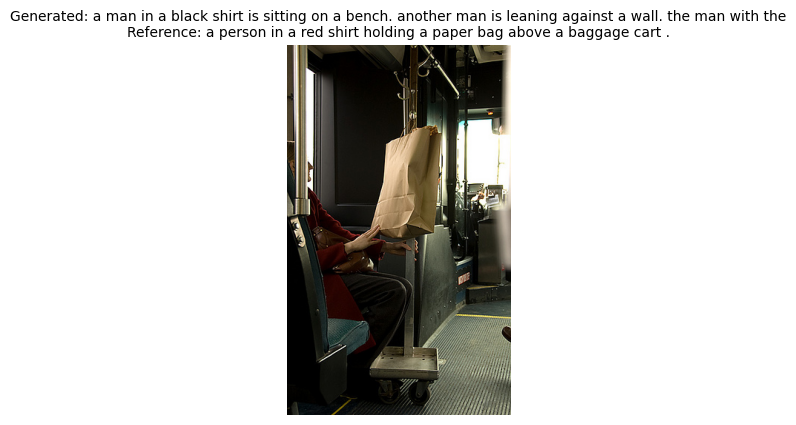

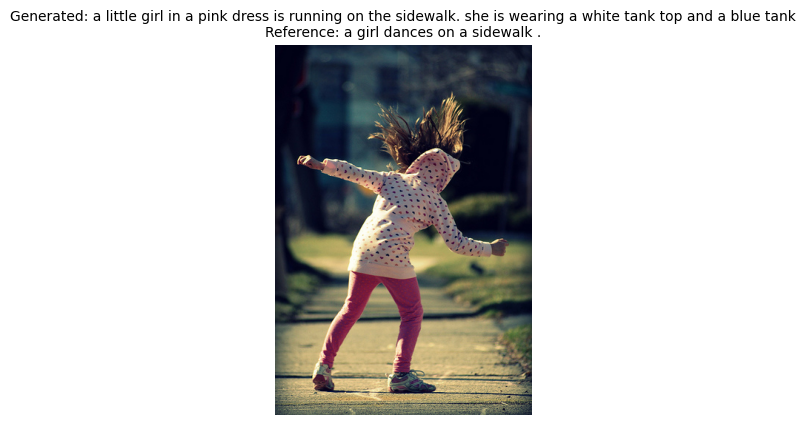

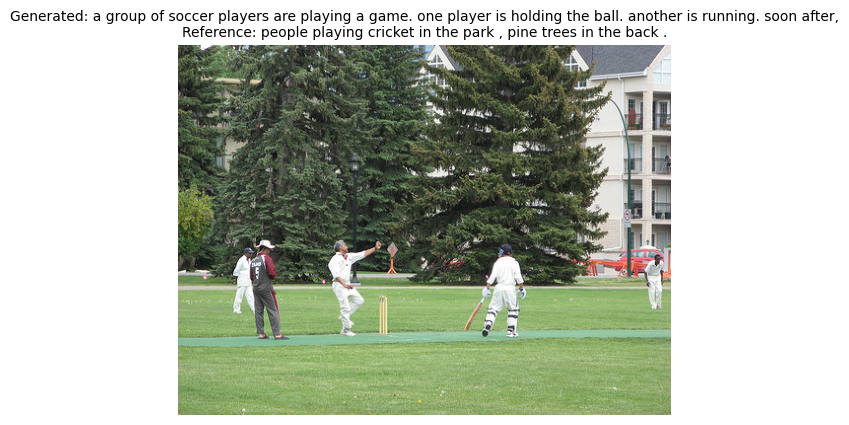

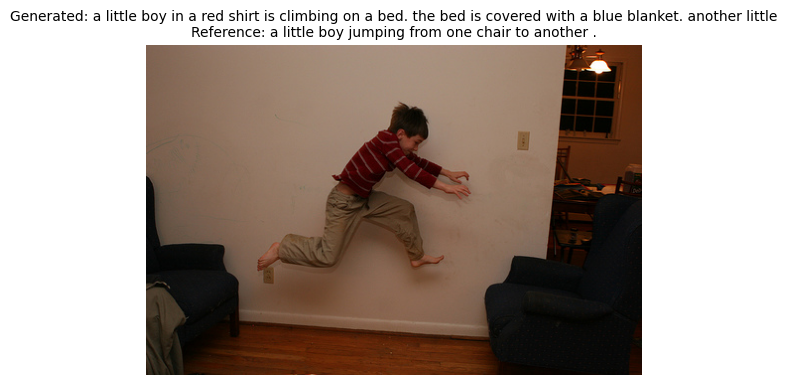

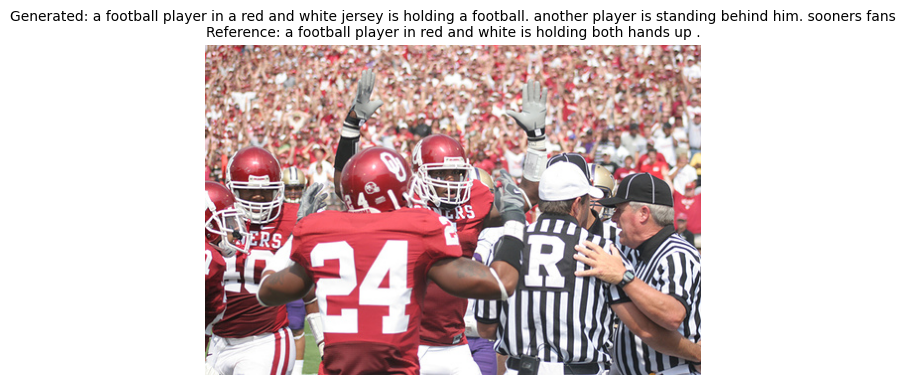

In [11]:
import matplotlib.pyplot as plt

for idx in range(5):
    iid = list(test_dict.keys())[idx]
    image_path = os.path.join(config.IMAGE_FOLDER_PATH, iid)
    image = Image.open(image_path)
    candidate = candidate_list[idx]['caption'][0]
    references = reference_list[idx]

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Generated: {candidate}\nReference: {references[0]}", fontsize=10)
    plt.show()

## Testing

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


🖼️ Testing on image: ../data/Images\1473618073_7db56a5237.jpg


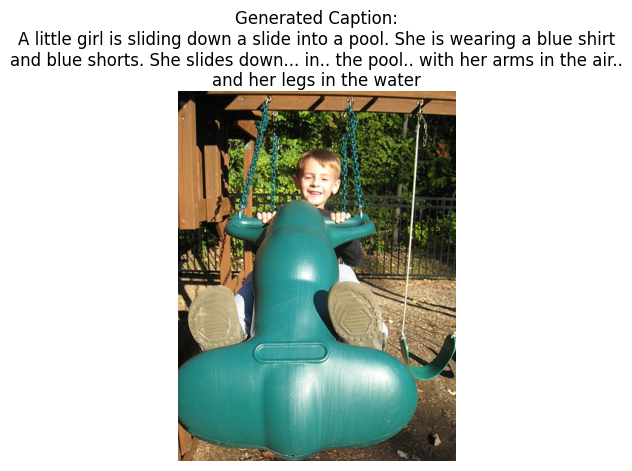


📝 Generated Caption:
A little girl is sliding down a slide into a pool. She is wearing a blue shirt and blue shorts. She slides down... in.. the pool.. with her arms in the air.. and her legs in the water


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

model_path = "MAE-ViT-GPT2-Flickr8k/best_model"
model = VisionEncoderDecoderModel.from_pretrained(model_path).to(DEVICE)
tokenizer = AutoTokenizer.from_pretrained(model_path)
image_processor = AutoImageProcessor.from_pretrained(config.ENCODER)

test_image_path = os.path.join(config.IMAGE_FOLDER_PATH, random.choice(test_ids))
print(f"🖼️ Testing on image: {test_image_path}")

image = Image.open(test_image_path).convert("RGB")
pixel_values = image_processor(images=image, return_tensors="pt").pixel_values.to(DEVICE)

model.eval()
with torch.no_grad():
    generated_ids = model.generate(
        pixel_values,
        num_beams=5,
        max_length=50,
        early_stopping=True,
        no_repeat_ngram_size=3
    )

generated_caption = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

plt.imshow(image)
plt.axis("off")
plt.title(f"Generated Caption:\n{generated_caption}", fontsize=12, wrap=True)
plt.show()

print("\n📝 Generated Caption:")
print(generated_caption)
